# Tutorial 1: Denoising on single-slice DLPFC data from 10x Visium 

In this tutorial, we demonstrate the denoising capabilities of STADIM using single-slice data. We use the human Dorsolateral Prefrontal Cortex (DLPFC) slice #151673 generated by 10x Visium platform as a representative example, which is annotated by Maynard et al. into white matter (WM) and cortical layers (L1-L6) based on marker genes and cellular structure.  
We download the data via http://spatial.libd.org/spatialLIBD/.  

## Quick view data

In [1]:
import anndata as ad

raw_data = ad.read_h5ad('/data2/xiaost/SODA/Data/DLPFC/dlpfc_151673.h5ad')

print(raw_data)

AnnData object with n_obs × n_vars = 3611 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [2]:
print(raw_data.obs.head(5))

                    in_tissue  array_row  array_col  sample Label
AACGTGATGAAGGACA-1          1          9         83  151673    L3
TGATTCCCGGTTACCT-1          1         64         50  151673    L6
CTTTGGCGCTTTATAC-1          1         32         18  151673    L4
ACGCTGTGAGGCGTAG-1          1         39         13  151673    L5
AGGTTACACCATGCCG-1          1         43        115  151673    L2


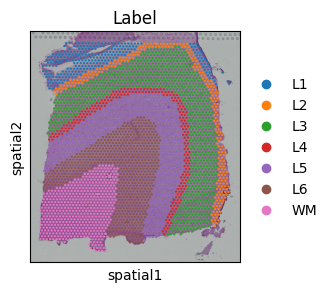

In [3]:
import scanpy as sc
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 3))
sc.pl.spatial(raw_data, color='Label', ax=ax, show=False)
plt.show()

## Run STADIM

You can call the STADIM command directly in your terminal:
```bash
nohup stadim --input "./dlpfc_151673.h5ad" --save_dir ./dlpfc_151673_test --device "cuda:0" --monitor --seed 2026 --min_genes 0 --min_cells 10 --knn_c 6 --knn_e 10 > ./dlpfc_151673_test.log 2>&1 &
```
and load the results into your Python environment for downstream analysis. The denoised expression matrix is conveniently stored within the `layers` attribute:
```python
import anndata as ad

adata = ad.read_h5ad('/dlpfc_151673_test/sdata.h5ad')

## The denoised gene expressionis is stored in adata.layers['STADIM']
print(adata)
```
or you can call STADIM within a Jupyter Notebook as follows:

In [4]:
import stadim

adata = stadim.run_STADIM(['/data2/xiaost/SODA/Data/DLPFC/dlpfc_151673.h5ad'], save_preprocessed_h5ad=None, save_dir=None, 
                          sample_names=None, batch_key='sample', device='cuda:1', seed=2026, 
                          min_genes=0, min_cells=10, nhvgs=2000, dim=50, knn_c=6, knn_e=10, mnn_n=25,
                          batch_size=256, triplets_update_ratio=0.8, hard_triplets_ratio=0.7,
                          epochs=100, lr=1e-3, loss_mode='nb', beta_trip=0.1,
                          encoder_layers=[512, 256, 64], decoder_layers=[1000])

Results will be stored in adata.layers['STADIM']

=== 1. Begin read_data!
Processing single slice: Using user-defined column 'sample'
Processing single slice: Keeping existing sample label 151673

Merging data...

Raw Merged Data: 3611 spots × 33538 genes
Unified Filtering (min_genes=0, min_cells=10)...
  → After Filtering: 3611 spots × 16567 genes
  ✓ Complete: Samples included: ['151673']
  ✓ Complete: AnnData object with n_obs × n_vars = 3611 × 16567
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'X_raw'

=== 2. Begin MY_preprocess!
== Selected 2000 HVGs across 1 slices

=== 3. Begin all_ap find neighbors!

=== 4. Begin pre_dataset!
{0: '151673'}


Preparing triplet: 100%|██████████| 3611/3611 [00:00<00:00, 6602.14it/s]



=== 5. Begin IterableTripletDataset!
Initializing triplets...
IterableTripletDataset Initialized: 3611 anchors, batch_size=256

=== 6. Begin calculate_recommended_margin!
Calculating recommended margin (averaging over 5 runs)...

Margins from 5 runs: [15.0, 15.0, 15.0, 15.0, 15.0]
Final Recommended Margin: 15.0000

=== 7. Starting training...
Begin training: device=cuda:1


Training: 100%|██████████| 100/100 [01:27<00:00,  1.14it/s, recon=0.366, triplet=3.448, total=0.711]



=== 8. Generating denoised expression...
   Data size (5.98e+07) is within limits. Allocating memory for denoised data.

All processes finished! Total time: 1.73 mins.


In [5]:
print(adata)

AnnData object with n_obs × n_vars = 3611 × 16567
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'Label', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'spatial', 'log1p', 'top_hvgs'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'STADIM'
    layers: 'X_raw', 'X_norm', 'X_log', 'STADIM', 'STADIM_withbatch'


## Analysis

In [6]:
import anndata as ad
import pandas as pd
import scanpy as sc 
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
gene_exp_colors = sns.blend_palette(["#C9E2FF", "#eae6cc", '#e31a1c'], n_colors=100)
gene_exp_palette = LinearSegmentedColormap.from_list("gene_exp", gene_exp_colors)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
plt.rcParams.update({
    'font.size': 16, 
    'axes.labelsize': 18,  
    'axes.titlesize': 18,  
    'xtick.labelsize': 16, 
    'ytick.labelsize': 16,  
    'legend.fontsize': 16,
})

gene_list = ['FABP7', 'RELN', 'HPCAL1', 'ADCYAP1', 'FREM3', 'CARTPT', 'PVALB', 'TRABD2A', 
             'PCP4', 'KRT17', 'NR4A2', 'NTNG2', 'MOBP', 'NDRG1', 'MBP']

gene_region = {
    'FABP7': 'L1', 'RELN': 'L1', 
    'HPCAL1': 'L2',
    'ADCYAP1': 'L3', 'FREM3': 'L3', 'CARTPT': 'L3',
    'PVALB': 'L4',
    'TRABD2A': 'L5', 'PCP4': 'L5',
    'KRT17': 'L6', 'NR4A2': 'L6', 'NTNG2': 'L6',
    'MOBP': 'WM', 'NDRG1': 'WM', 'MBP': 'WM'
}

### Gene expression visualization

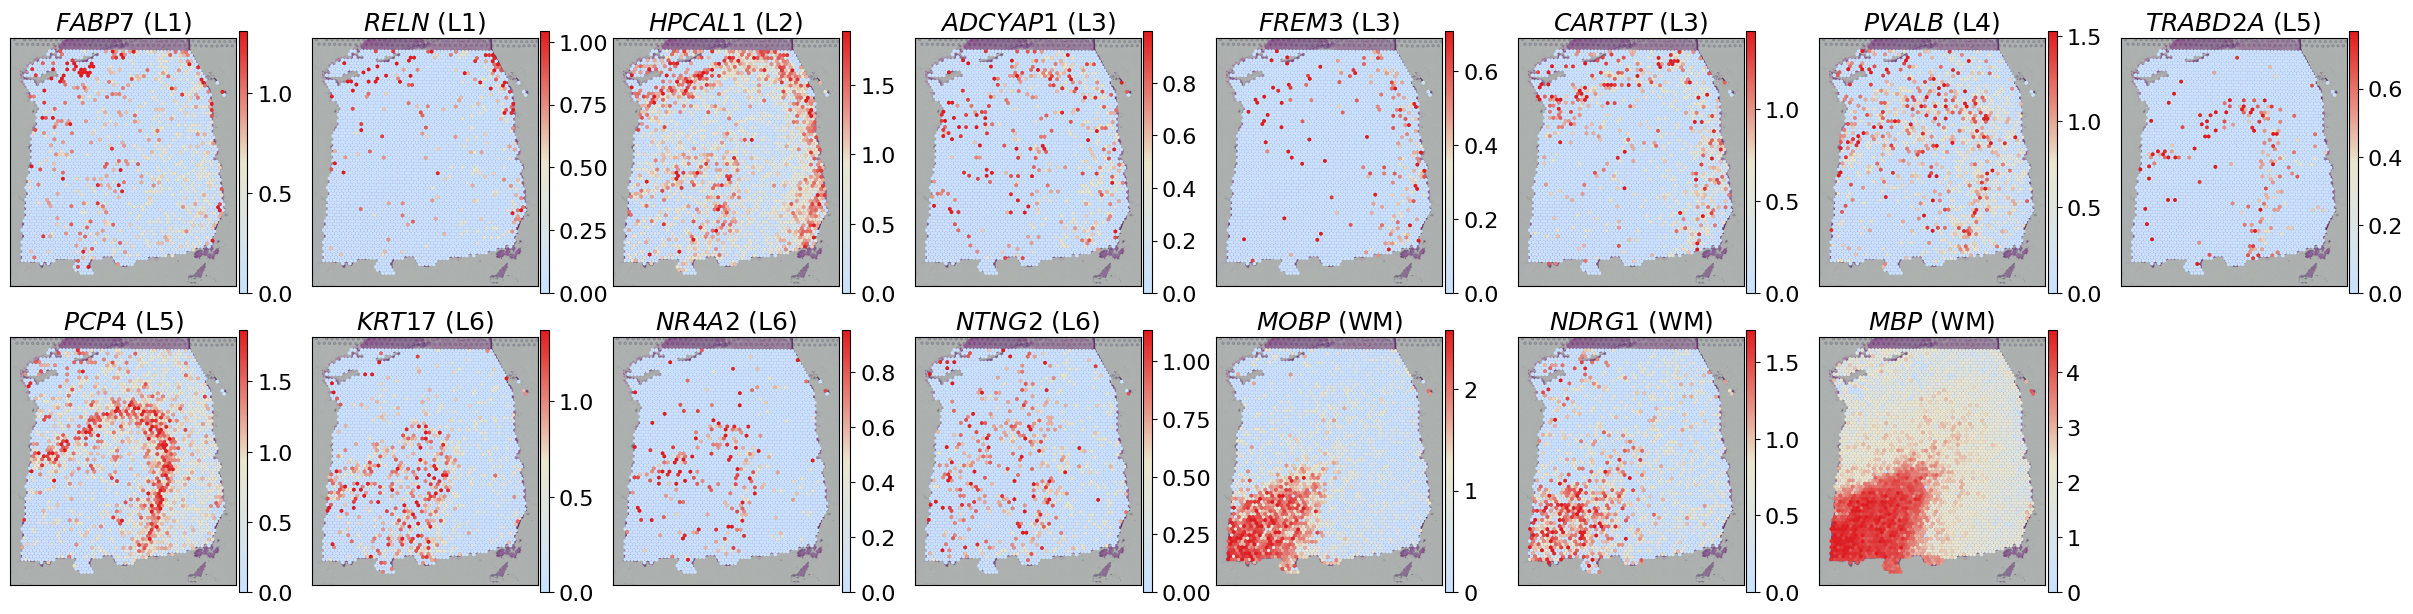

In [7]:
fig, axes = plt.subplots(2, 8, figsize=(24, 6))
axes = axes.flatten()

for i, gene in enumerate(gene_list):
    sc.pl.spatial(adata, layer='X_log', color=gene, cmap=gene_exp_palette, spot_size=150, ax=axes[i], show=False, img_key='hires', 
                  vmax="p99", title=f"$\mathit{{{gene}}}$ ({gene_region[gene]})")
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
axes[-1].axis('off')

plt.tight_layout(pad=0.1)
plt.show()

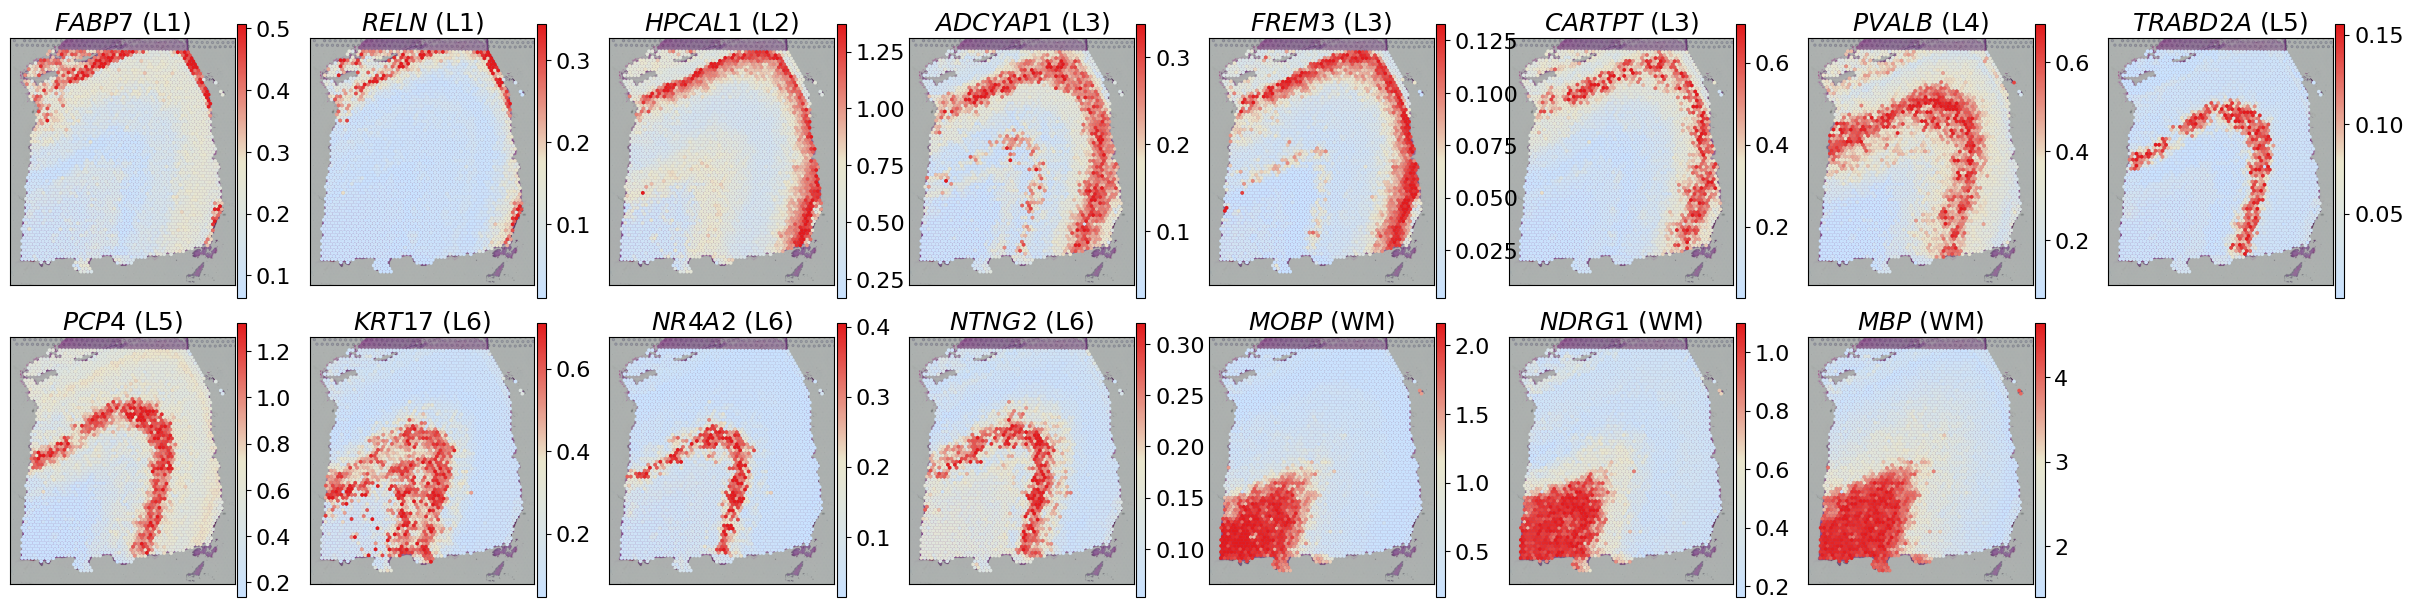

In [8]:
adata.X = adata.layers['STADIM'].copy()
sc.pp.log1p(adata)
adata.layers['STADIM_log'] = adata.X.copy()

fig, axes = plt.subplots(2, 8, figsize=(24, 6))
axes = axes.flatten()

for i, gene in enumerate(gene_list):
    sc.pl.spatial(adata, layer='STADIM_log', color=gene, cmap=gene_exp_palette, spot_size=150, ax=axes[i], show=False, img_key='hires', 
                  vmax="p99", title=f"$\mathit{{{gene}}}$ ({gene_region[gene]})")
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
axes[-1].axis('off')

plt.tight_layout(pad=0.1)
plt.show()

### Evaluation metrics

In [9]:
import os
import sys
from contextlib import redirect_stdout

results = []

for layer in ['X_norm', 'STADIM']:
    for gene, region in gene_region.items():
        expr = adata.layers[layer][:, adata.var_names.get_loc(gene)]
        expr = expr.toarray().flatten() if hasattr(expr, 'toarray') else np.array(expr).flatten()
        
        mask = adata.obs['Label'] == region
        target_val = expr[mask]
        bg_val = expr[~mask]

        with open(os.devnull, 'w') as fnull:
            with redirect_stdout(fnull):
                moran = stadim.calculate_new_morani(adata, [layer], {gene: region})
        
        results.append({
            'Method': layer,
            'Gene': gene,
            'Region': region,
            'Tau': stadim.calculate_tau_index(expr, adata.obs['Label']),
            'FC': stadim.calculate_fold_change(target_val, bg_val),
            'Cohens_D': stadim.calculate_cohens_d(target_val, bg_val),
            'Global_Moran': moran['Global_Moran'].values[0],
            'Background_Moran': moran['Background_Moran'].values[0],
            'newI': moran['newI'].values[0]
        })

df_res = pd.DataFrame(results)

In [10]:
for layer in ['X_norm', 'STADIM']:
    print(f"\n=== Detailed Metrics for {layer} ===")
    layer_df = df_res[df_res['Method'] == layer]
    display(layer_df)

print("\n=== Final Summary (Averaged across all genes) ===")
summary = df_res.groupby('Method')[['Tau', 'FC', 'Cohens_D', 'Global_Moran', 'Background_Moran', 'newI']].mean()
display(summary.sort_values('newI', ascending=False))


=== Detailed Metrics for X_norm ===


,Method,Gene,Region,Tau,FC,Cohens_D,Global_Moran,Background_Moran,newI
0,X_norm,FABP7,L1,0.679730,3.176126,0.721098,0.089367,0.036577,0.526395
1,X_norm,RELN,L1,0.833288,7.612881,0.775069,0.109547,0.045728,0.531910
2,X_norm,HPCAL1,L2,0.699730,3.068554,1.360526,0.221055,0.135886,0.542585
3,X_norm,ADCYAP1,L3,0.561619,2.554207,0.353631,0.051692,0.009240,0.521226
4,X_norm,FREM3,L3,0.714852,3.003668,0.259095,0.047120,0.017907,0.514607
5,X_norm,CARTPT,L3,0.594013,3.195088,0.478894,0.124311,0.063235,0.530538
6,X_norm,PVALB,L4,0.596678,2.239379,0.565294,0.074833,0.057134,0.508850
7,X_norm,TRABD2A,L5,0.841705,7.867309,0.623517,0.071052,-0.006673,0.532189
8,X_norm,PCP4,L5,0.697033,3.536765,1.128401,0.253894,0.066206,0.593844
9,X_norm,KRT17,L6,0.758341,3.998996,0.796877,0.125162,0.045310,0.539926



=== Detailed Metrics for STADIM ===


,Method,Gene,Region,Tau,FC,Cohens_D,Global_Moran,Background_Moran,newI
15,STADIM,FABP7,L1,0.581135,2.441201,3.132529,0.818420,0.757170,0.530625
16,STADIM,RELN,L1,0.717490,4.364239,2.716194,0.814868,0.769424,0.522722
17,STADIM,HPCAL1,L2,0.662147,2.710248,3.049344,0.857274,0.783988,0.536643
18,STADIM,ADCYAP1,L3,0.531298,2.405351,2.059148,0.814738,0.609914,0.602412
19,STADIM,FREM3,L3,0.667070,2.597443,1.546577,0.877676,0.704484,0.586596
20,STADIM,CARTPT,L3,0.568594,3.103972,2.004034,0.847647,0.755061,0.546293
21,STADIM,PVALB,L4,0.525031,1.971619,1.827773,0.845831,0.791697,0.527067
22,STADIM,TRABD2A,L5,0.802766,5.740999,2.960346,0.812605,0.380765,0.715920
23,STADIM,PCP4,L5,0.561332,2.447884,2.470404,0.835366,0.781112,0.527127
24,STADIM,KRT17,L6,0.741785,3.666232,2.546959,0.807889,0.594334,0.606777



=== Final Summary (Averaged across all genes) ===


,Tau,FC,Cohens_D,Global_Moran,Background_Moran,newI
Method,,,,,,
STADIM,0.674331,3.942495,2.956815,0.855890,0.711164,0.572363
X_norm,0.717934,4.618325,1.168274,0.209013,0.108876,0.549624


### Label specific markers

In [11]:
def get_markers(adata, layer, n_top=100):
    key = f'rank_{layer}'
    sc.tl.rank_genes_groups(adata, 'Label', method='wilcoxon', layer=layer, key_added=key)
    df = sc.get.rank_genes_groups_df(adata, group=None, key=key)
    # Add rank and filter top N
    df['Rank'] = df.groupby('group').cumcount() + 1
    return df[df['Rank'] <= n_top][['names', 'group', 'Rank']].rename(columns={'names':'Gene', 'group':'Label'})

# 1. Get Top 100 markers for both layers
df_norm = get_markers(adata, 'X_log')
df_stadim = get_markers(adata, 'STADIM_log')

# 2. Merge to find common and unique pairs
merged = pd.merge(df_norm, df_stadim, on=['Gene', 'Label'], how='outer', suffixes=('_norm', '_stadim'), indicator=True)

common = merged[merged['_merge'] == 'both']
unique_norm = merged[merged['_merge'] == 'left_only']
unique_stadim = merged[merged['_merge'] == 'right_only']

# 3. Quick Stats Report
print(f"--- Marker Stats (Gene-Label Pairs) ---")
print(f"Common: {len(common)} | Unique Norm: {len(unique_norm)} | Unique STADIM: {len(unique_stadim)}")

# 4. Specificity Analysis: Multi-label genes (Noise Reduction)
multi_norm = df_norm.groupby('Gene')['Label'].nunique()
multi_stadim = df_stadim.groupby('Gene')['Label'].nunique()

# Genes that are multi-label in Norm but single-label (specific) in STADIM
denoised_genes = list(set(multi_norm[multi_norm > 1].index) & set(multi_stadim[multi_stadim == 1].index))

print(f"\n--- Specificity & Noise Reduction ---")
print(f"Multi-label genes in Norm: {sum(multi_norm > 1)}")
print(f"Multi-label genes in STADIM: {sum(multi_stadim > 1)}")
print(f"Denoised genes (Multi-label -> Single-label): {len(denoised_genes)}")

if denoised_genes:
    print(f"Denoised gene examples: {denoised_genes[:10]}")

--- Marker Stats (Gene-Label Pairs) ---
Common: 154 | Unique Norm: 546 | Unique STADIM: 546

--- Specificity & Noise Reduction ---
Multi-label genes in Norm: 162
Multi-label genes in STADIM: 0
Denoised genes (Multi-label -> Single-label): 34
Denoised gene examples: ['CRYAB', 'DIRAS2', 'UBE2QL1', 'HS3ST2', 'NEFL', 'MAG', 'CAMK2N1', 'ENC1', 'CLDND1', 'ATP5F1B']


In [12]:
merged[merged['Gene'] == 'CAMK2N1']

,Gene,Label,Rank_norm,Rank_stadim,_merge
192,CAMK2N1,L1,31.0,NaN,left_only
193,CAMK2N1,L2,1.0,8.0,both
194,CAMK2N1,L3,28.0,NaN,left_only


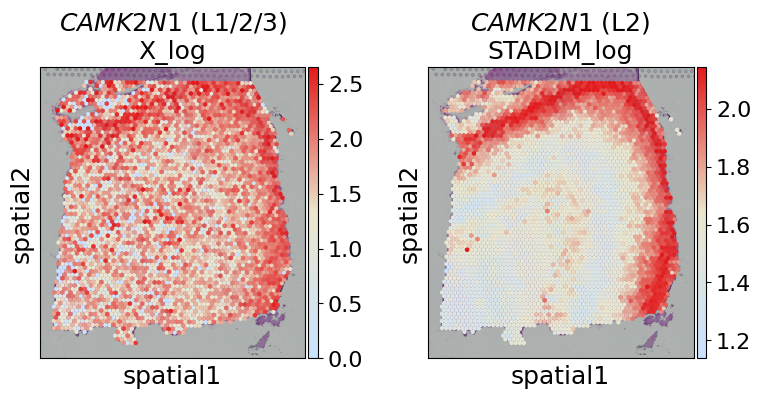

In [13]:
gene = 'CAMK2N1'
labels_gene = ['L1/2/3', 'L2']
layers = ['X_log', 'STADIM_log']

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i, layer in enumerate(layers):
    sc.pl.spatial(adata, layer=layer, color=gene, cmap=gene_exp_palette, spot_size=150, vmax='p99',
                  ax=axes[i], show=False, title=f"$\mathit{{{gene}}}$ ({labels_gene[i]})\n{layer}")

plt.tight_layout()
plt.show()

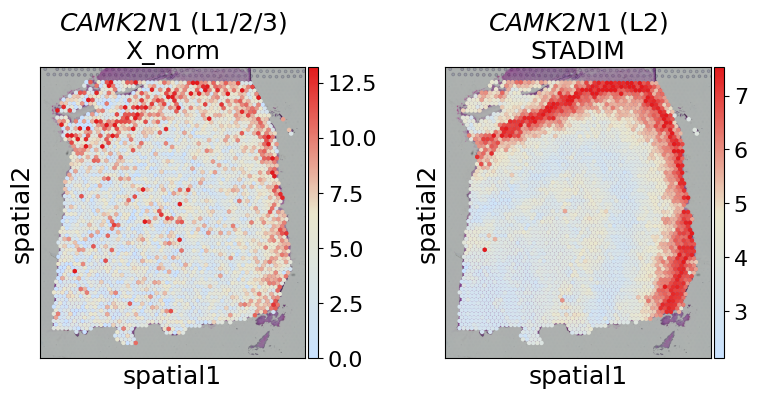

In [14]:
gene = 'CAMK2N1'
labels_gene = ['L1/2/3', 'L2']
layers = ['X_norm', 'STADIM']

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i, layer in enumerate(layers):
    sc.pl.spatial(adata, layer=layer, color=gene, cmap=gene_exp_palette, spot_size=150, vmax='p99',
                  ax=axes[i], show=False, title=f"$\mathit{{{gene}}}$ ({labels_gene[i]})\n{layer}")

plt.tight_layout()
plt.show()